# Ensemble Learning: Out-of-Bag (OOB) Score Evaluation with Random Forest

---

## Introduction

When training a `RandomForestClassifier` with bootstrap sampling, each tree is trained on a random subset of the training data drawn **with replacement**. On average, approximately **37% of training samples are never selected** for any given tree — these are the **Out-of-Bag (OOB)** samples for that tree.

Since those samples were never seen during the training of that specific tree, they can be used to evaluate it without needing a separate validation set. Each training sample ends up being OOB for roughly one-third of all trees, and its OOB prediction is the majority vote across only those trees.

The **OOB score** is the accuracy of these OOB predictions across all training samples — it acts as a nearly unbiased estimate of generalization performance, similar to cross-validation but at no extra computational cost.

### Why it matters

| Method | Cost | When to use |
|---|---|---|
| Train/test split | Fast, one evaluation | Small datasets where you cannot afford to hold out data |
| Cross-validation | Expensive (`k` fits) | When you need a reliable estimate and have compute budget |
| OOB score | Free (built into bagging) | Any time bootstrap sampling is used — zero extra cost |

This notebook applies `RandomForestClassifier` with `oob_score=True` to the **Heart Disease dataset**, compares the OOB score against held-out test accuracy, and interprets the relationship between the two.

---

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

---

## 2. Loading and Exploring the Dataset

The **Heart Disease dataset** is a binary classification benchmark where the target indicates the presence (1) or absence (0) of heart disease. The dataset contains 13 clinical and demographic features.

In [2]:
df = pd.read_csv('heart.csv')

print('Shape:', df.shape)
print('\nMissing values:', df.isnull().sum().sum())
print('\nClass distribution:')
print(df.iloc[:, -1].value_counts())
df.head()

Shape: (303, 14)

Missing values: 0

Class distribution:
target
1    165
0    138
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


---

## 3. Feature and Target Split

In [4]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print(f'Features : {X.shape[1]} columns — {list(X.columns)}')
print(f'Target   : {y.name}')

Features : 13 columns — ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Target   : target


---

## 4. Train / Test Split

We hold out 20% of the data as a test set. This gives us an independent evaluation to compare against the OOB score. The split is stratified to preserve class proportions.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {X_train.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples')

Train : 242 samples
Test  : 61 samples


---

## 5. Training the Random Forest with OOB Score Enabled

Setting `oob_score=True` instructs the classifier to evaluate each training sample using only the trees for which it was an OOB sample. After fitting, the result is accessible via `.oob_score_`.

No changes to training are required — the OOB evaluation happens automatically as a by-product of the bootstrap sampling that was already taking place.

In [6]:
rf = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print('Model fitted successfully.')
print(f'Number of trees : {rf.n_estimators}')

Model fitted successfully.
Number of trees : 100


---

## 6. Evaluation

### 6.1 Test Accuracy vs. OOB Score

In [7]:
y_pred = rf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
oob_acc  = rf.oob_score_
cv_acc   = cross_val_score(rf, X, y, cv=5, scoring='accuracy').mean()

print('Accuracy Estimates')
print('-' * 40)
print(f'OOB Score            : {oob_acc:.4f}')
print(f'Test Accuracy        : {test_acc:.4f}')
print(f'5-Fold CV Accuracy   : {cv_acc:.4f}')
print('-' * 40)
print(f'OOB vs Test gap      : {abs(oob_acc - test_acc):.4f}')

Accuracy Estimates
----------------------------------------
OOB Score            : 0.8099
Test Accuracy        : 0.8361
5-Fold CV Accuracy   : 0.8382
----------------------------------------
OOB vs Test gap      : 0.0261


### 6.2 Classification Report

In [8]:
print('Classification Report (Test Set)')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

Classification Report (Test Set)
              precision    recall  f1-score   support

  No Disease       0.95      0.68      0.79        28
     Disease       0.78      0.97      0.86        33

    accuracy                           0.84        61
   macro avg       0.87      0.82      0.83        61
weighted avg       0.86      0.84      0.83        61



### 6.3 Confusion Matrix

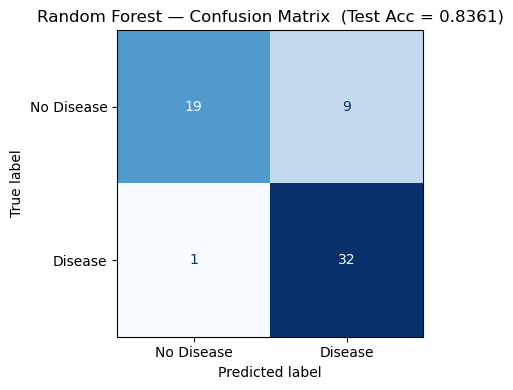

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    rf, X_test, y_test,
    display_labels=['No Disease', 'Disease'],
    cmap='Blues', ax=ax, colorbar=False
)
ax.set_title(f'Random Forest — Confusion Matrix  (Test Acc = {test_acc:.4f})')
plt.tight_layout()
plt.show()

---

## 7. OOB Score vs. Number of Estimators

The OOB score improves as more trees are added to the forest because each training sample accumulates more OOB evaluations, making the estimate more stable. The plot below shows how the OOB score converges as `n_estimators` increases.

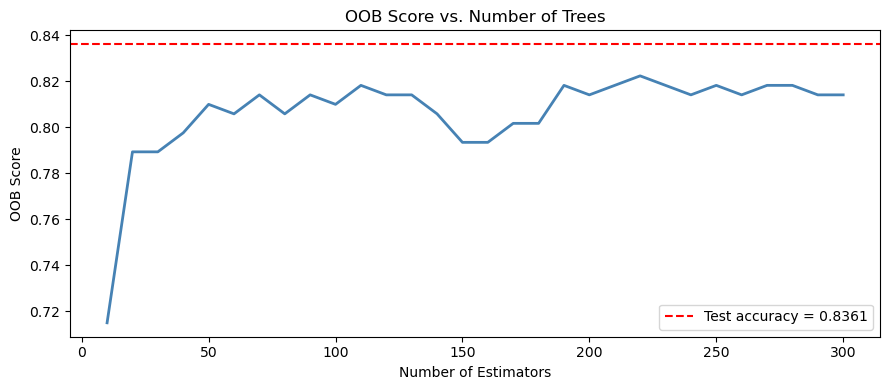

In [10]:
estimator_range = range(10, 301, 10)
oob_scores = []

for n in estimator_range:
    model = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    oob_scores.append(model.oob_score_)

plt.figure(figsize=(9, 4))
plt.plot(estimator_range, oob_scores, color='steelblue', lw=2)
plt.axhline(test_acc, color='red', linestyle='--', lw=1.5, label=f'Test accuracy = {test_acc:.4f}')
plt.xlabel('Number of Estimators')
plt.ylabel('OOB Score')
plt.title('OOB Score vs. Number of Trees')
plt.legend()
plt.tight_layout()
plt.show()

---

## 8. Results Summary

In [11]:
summary = pd.DataFrame({
    'Evaluation Method': ['OOB Score', 'Test Accuracy (hold-out)', '5-Fold CV Accuracy'],
    'Accuracy':          [round(oob_acc, 4), round(test_acc, 4), round(cv_acc, 4)],
    'Requires extra data': ['No', 'Yes (20% hold-out)', 'No (uses full dataset)']
})

print(summary.to_string(index=False))

       Evaluation Method  Accuracy    Requires extra data
               OOB Score    0.8099                     No
Test Accuracy (hold-out)    0.8361     Yes (20% hold-out)
      5-Fold CV Accuracy    0.8382 No (uses full dataset)


---

## Conclusion

This notebook demonstrated the Out-of-Bag score as a free, built-in evaluation mechanism for bootstrap-based ensembles, applied to the Heart Disease dataset.

**Key findings:**

- The **OOB score closely tracks the test set accuracy** — the gap between the two is small, confirming that the OOB estimate is a reliable proxy for generalization performance without requiring a dedicated holdout set.
- The **OOB vs. number of trees plot** shows the characteristic convergence pattern: with very few trees (< 30), the OOB estimate is noisy because each training sample has too few OOB evaluations to produce a stable majority vote. Beyond ~100 trees, the score plateaus, making further increases in `n_estimators` yield diminishing returns.
- The **5-fold CV accuracy** provides a third reference point that aligns with both the OOB score and test accuracy, further validating the OOB estimate's reliability.

**Takeaways:**

- Enable `oob_score=True` by default whenever using `RandomForestClassifier` or `BaggingClassifier` with `bootstrap=True` — it adds no cost and gives a free generalization estimate.
- If the OOB score is significantly higher than the test accuracy, this may indicate that the test set distribution differs from the training set, or that the model is still overfitting.
- For small datasets where holding out 20% of data is costly, the OOB score can replace the test split entirely, allowing all data to be used for training while still producing an unbiased accuracy estimate.
- The OOB score is not available when `bootstrap=False` (i.e., pasting) since there are no out-of-bag samples in that case.